In [1]:
import numpy as np
import json
import pandas as pd
# import pyarrow.parquet as pq
from tqdm.auto import tqdm
import os
import xgboost as xgb
import matplotlib.pyplot as plt
from pathlib import Path
import pickle
import hist
import importlib
from hbb import utils 

# le = OrdinalEncoder

import mplhep as hep
plt.style.use([hep.style.CMS])
from common_bb_cc import common_mc
import batch_iterator
importlib.reload(batch_iterator)
from batch_iterator import Iterator
import matplotlib.colors as mcolors
colors = list(mcolors.TABLEAU_COLORS.keys())

# plt.style.use([hep.style.CMS])
# from sklearn.model_selection import train_test_split

SyntaxError: unterminated string literal (detected at line 5) (3629325456.py, line 5)

In [2]:
booster = xgb.XGBClassifier()
booster.load_model('./BatchedBDT_4Cat_26Sep21_LessVars.json')

omit_cols = ['category','y', 'weight', 'finalWeight', 'sum_genWeight', 'weight_nonorm', 'BDT_weight', 'BDT_cat_weight', 'BDT_era_weight', 'FatJet0_pt', 'FatJet0_msd']

# dir(booster) 
# omit_cols = ['isSignal', 'weight','weight_final', 'BDT_score',
#              'category', 'FatJet0_pt', 'FatJet0_msd', 'FatJet0_msdmatched',
#              'MC_name', 'y', 'sumW', 'genWeight',
#              'Photon110EB_TightID_TightIso', 'Photon30EB_TightID_TightIso',
#              'FatJet0_pnetMass', 'FatJet0_pnetTXbb', 'FatJet0_pnetTXgg',
#              'FatJet0_pnetTXcc', 'FatJet0_pnetTXqq', 'FatJet0_pnetXbbXcc', 'FatJet0_pnetTQCD',
#              'FatJet0_ParTPQCD', 'FatJet0_ParTPXbb', 'FatJet0_ParTPXcc',
#               'FatJet0_ParTPXqq', 'FatJet0_ParTPXcs', 'FatJet0_ParTPXbbVsQCD',
#              'FatJet0_ParTPTopbWq', 'FatJet0_ParTPTopbWqq',
#              'Photon200', 'FatJet0_ParTPXccVsQCD', 'FatJet0_ParTPXbbXcc', 'FatJet0_ParTmassX2p',
#              'FatJet1_pnetMass', 'FatJet1_pnetTXbb', 'FatJet1_pnetTXcc',
#              'FatJet1_pnetTXqq', 'FatJet1_pnetTXgg',
#              'Photon0_eta', 'Photon0_phi', 'Photon0_pt',
#              'AK8PFJet250_SoftDropMass40_PFAK8ParticleNetBB0p35',
#            'QuadPFJet70_50_40_35_PFBTagParticleNet_2BTagSum0p65',
#            'AK8PFJet425_SoftDropMass40', 'PFJet500', 'PFHT1050', 'BDT_cat_weight',
#             'Jet0_btagPNetB', 'Jet0_btagPNetCvB', 'Jet0_btagPNetCvL', 
#              'Jet1_btagPNetB', 'Jet1_btagPNetCvB', 'Jet1_btagPNetCvL', 
#              'Jet2_btagPNetB', 'Jet2_btagPNetCvB', 'Jet2_btagPNetCvL', 
#              'Jet3_btagPNetB', 'Jet4_btagPNetCvB', 'Jet4_btagPNetCvL', 
#              'FatJet1_ParTPXbbVsQCD', 'FatJet1_ParTPXccVsQCD', 'FatJet1_ParTPXbbXcc',
#             'nJet_outsideFatJet0_medBtag', 'FatJet1_ParTPZvsQCD']

# val_files = ['4cat_BDTdata_Xtest.parquet']

data_dir = "/uscms/home/bweiss/nobackup/hbb-run3/data/4cat_BDT_data_22_newSkim_LessVars"
file_paths = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith(".parquet")]
# metadata_dir = os.path.join(data_dir, "metadata.pkl")
# train_files = file_paths[:4]
val_files = file_paths[4:]

test_file = pd.read_parquet(val_files[0])
Y_predict = booster.predict_proba(test_file.drop(omit_cols, axis=1))


In [3]:
cols = booster.get_booster().feature_names
print(cols)
print(len(cols))

['nFatJet', 'nJet', 'FatJet0_phi', 'FatJet0_eta', 'FatJet0_n2b1', 'FatJet0_n3b1', 'FatJet1_pt', 'FatJet1_phi', 'FatJet1_eta', 'FatJet1_msd', 'VBFPair_mjj', 'VBFPair_deta', 'FatJet1_ParTPQCD', 'FatJet1_ParTPXbb', 'FatJet1_ParTPXcc', 'FatJet1_ParTPXqq', 'FatJet1_ParTPXcs', 'FatJet1_ParTmassX2p', 'Jet0_pt', 'Jet0_eta', 'Jet0_phi', 'Jet0_mass', 'Jet0_btagPNetQvG', 'Jet1_pt', 'Jet1_eta', 'Jet1_phi', 'Jet1_mass', 'Jet1_btagPNetQvG', 'Jet2_pt', 'Jet2_eta', 'Jet2_phi', 'Jet2_mass', 'Jet2_btagPNetQvG', 'Jet3_pt', 'Jet3_eta', 'Jet3_phi', 'Jet3_mass', 'Jet4_btagPNetQvG', 'JetClosestFatJet0_pt', 'JetClosestFatJet0_eta', 'JetClosestFatJet0_phi', 'JetClosestFatJet0_mass', 'FatJet1_ParTPTopbWq', 'FatJet1_ParTPTopbWqq', 'nJet_outsideFatJet0', 'nJet_opphemFatJet0', 'JetClosestFatJet0_dR', 'JetClosestFatJet0_dijetMass', 'era']
49


In [17]:
''' Purity plot'''


# colors = ['blue', 'red', 'green', 'purple', 'orange']
cat2label = {"vbf": 0,
             "vh": 1 ,
             "ggf": 2 ,
             "ttbar": 3
            }
# cat2label = {"VBF": 0,
#              "VH": 1 ,
#              "ggF": 2 ,
#              "ttbar": 3
#             }
label2cat = {0: "vbf",
             1: "vh" ,
             2: "ggf",
             3: "ttbar"
            }
# label2cat = {0: "VBF",
#              1: "VH" ,
#              2: "ggF",
#              3: "ttbar"
#             }

omit_cols = ['category','y', 'weight', 'finalWeight', 'sum_genWeight', 'weight_nonorm', 'BDT_weight', 'BDT_cat_weight', 'BDT_era_weight', 'FatJet0_pt', 'FatJet0_msd']
# omit_cols = ['isSignal', 'weight','weight_final', 'BDT_score',
#              'category', 'FatJet0_pt', 'FatJet0_msd', 'FatJet0_msdmatched',
#              'MC_name', 'y', 'sumW', 'genWeight',
#              'Photon110EB_TightID_TightIso', 'Photon30EB_TightID_TightIso',
#              'FatJet0_pnetMass', 'FatJet0_pnetTXbb', 'FatJet0_pnetTXgg',
#              'FatJet0_pnetTXcc', 'FatJet0_pnetTXqq', 'FatJet0_pnetXbbXcc', 'FatJet0_pnetTQCD',
#              'FatJet0_ParTPQCD', 'FatJet0_ParTPXbb', 'FatJet0_ParTPXcc',
#               'FatJet0_ParTPXqq', 'FatJet0_ParTPXcs', 'FatJet0_ParTPXbbVsQCD',
#              'FatJet0_ParTPTopbWq', 'FatJet0_ParTPTopbWqq',
#              'Photon200', 'FatJet0_ParTPXccVsQCD', 'FatJet0_ParTPXbbXcc', 'FatJet0_ParTmassX2p',
#              'FatJet1_pnetMass', 'FatJet1_pnetTXbb', 'FatJet1_pnetTXcc',
#              'FatJet1_pnetTXqq', 'FatJet1_pnetTXgg',
#              'Photon0_eta', 'Photon0_phi', 'Photon0_pt',
#              'AK8PFJet250_SoftDropMass40_PFAK8ParticleNetBB0p35',
#            'QuadPFJet70_50_40_35_PFBTagParticleNet_2BTagSum0p65',
#            'AK8PFJet425_SoftDropMass40', 'PFJet500', 'PFHT1050', 'BDT_cat_weight']

def score_cut(Y, WP_dict={}):
    '''converts score probabilities into class predictions according to WP_dict'''
    '''replaces the argmax() category definition'''
    output = np.full(len(Y), -1)
    pass_masks = {}
    for cat, lab in cat2label.items():
        pass_masks[cat] = Y[:,lab] > WP_dict[cat]
    for cat, lab in cat2label.items():
        other_masks = [m for c,m in pass_masks.items() if c !=cat ]
        not_others = ~np.any(other_masks, axis=0)
        # not_others = np.zeros(len(Y), dtype=bool)
        # for c in pass_mask.keys():
        #     if c != cat:
        #         not_others &= ~pass_mask[c]
        output[pass_masks[cat] & not_others] = lab
    return output
WP_dict = {
    'vbf':0.5,
    'vh':0.5,
    'ggf':0.2,
    'ttbar':0.3,
}

print(Y_predict[:20])
print(np.argmax(Y_predict, axis = 1))
SC_Y = score_cut(Y_predict, WP_dict=WP_dict)
print(SC_Y)


[[0.05924098 0.45789486 0.39172795 0.09113619]
 [0.07731702 0.113443   0.77611107 0.03312894]
 [0.16975228 0.23860551 0.469846   0.12179621]
 [0.00556618 0.11357553 0.09555528 0.78530306]
 [0.32878846 0.19078925 0.43111464 0.04930767]
 [0.06485605 0.750624   0.1088272  0.07569281]
 [0.02816111 0.699269   0.15767986 0.11488999]
 [0.2851773  0.0750382  0.56913924 0.07064521]
 [0.00965955 0.10428099 0.80810934 0.07795012]
 [0.00456196 0.12831151 0.05462382 0.81250274]
 [0.01357126 0.41622373 0.23151566 0.3386894 ]
 [0.08328371 0.09306716 0.77067107 0.05297806]
 [0.19847722 0.03576881 0.74443513 0.02131879]
 [0.38441637 0.1166283  0.4169679  0.08198737]
 [0.31972018 0.19005024 0.395485   0.09474459]
 [0.04424158 0.15758511 0.6603576  0.13781571]
 [0.06847759 0.19083892 0.6112077  0.12947574]
 [0.23147914 0.12951776 0.4146938  0.22430931]
 [0.015218   0.065436   0.8756149  0.04373113]
 [0.0156578  0.06223074 0.8473583  0.07475315]]
[1 2 2 ... 1 3 3]
[ 2  2  2 ...  3  3 -1]


In [20]:
def SCpurity_plot(ax, x_test, category = '', use_weights = False, label =''): # produce a stacked histogram bar with the makeup of that category
    # cat_mask = X_test['category'] == category
    
    if category == 'ttbar':
        ax.set_yscale('log')
        ax.set_ylim([1e-5,1])
        order=[0,1,2,3]
    else:
        ax.set_ylim([0,1])
        order = [0,1,2,]

    
    Y_predict = booster.predict_proba(x_test.drop(omit_cols, axis=1))
    # Y_predict = booster.predict(x_test.drop(omit_cols, axis=1))
    # print(Y_predict[:40])
    
    Y_predict = score_cut(Y_predict, WP_dict=WP_dict)
    
    cat_index = cat2label[category]
    pred_mask = Y_predict == cat_index
    X_pred = x_test[pred_mask]
    # print(X_pred)
    use_weights = int(use_weights)
    yields = np.zeros((4,2))
    bottom = 0
    for cat in order:
        truecat = label2cat[cat]
        print(cat, truecat)
        cat_mask = X_pred['category'] == truecat
        print(f'N {truecat}: ', np.sum(X_pred['finalWeight'][cat_mask].values, axis = 0))
        yields[cat][:] = [np.sum(cat_mask), 
                          np.sum(X_pred['finalWeight'][cat_mask].values, axis = 0)]
        # print(f'N {truecat}: ', np.sum(X_pred['weight_final'][cat_mask].values, axis = 0))
        # yields[cat][:] = [np.sum(cat_mask), 
        #                   np.sum(X_pred['weight_final'][cat_mask].values, axis = 0)]
    
    sumw = np.sum(yields[:,1])
    yields[:,1] = yields[:,1]/ np.sum(yields[:,1])
    # print(yields)            
    
    for c in order:
    #     if c ==3:
    #         color = colors[4]
    #     else:
    #         color = colors[c]
        ax.bar(category, yields[c, use_weights], bottom=bottom, color = colors[c], label = label2cat[c])
        bottom += yields[c,use_weights]
    
        ax.set_title(f'yield=\n {round(sumw, 1)}', fontsize=16)
    print("----------------------------------------")
    print(f'Predicted {category} purity: {yields[cat_index,1]})')
    print(f'contains {yields[0][0]} VBF, {yields[1][0]} VH, {yields[2][0]} ggF')
    print(f'with yields: {yields[0][1]} VBF, {yields[1][1]} VH, {yields[2][1]} ggF')

vbf
vh
ggf
ttbar
0 vbf
N vbf:  8.75552561262896
1 vh
N vh:  0.13850429431780575
2 ggf
N ggf:  3.583589403656994
----------------------------------------
Predicted vbf purity: 0.7016984085408279)
contains 539.0 VBF, 632.0 VH, 4156.0 ggF
with yields: 0.7016984085408279 VBF, 0.011100217987905892 VH, 0.2872013734712663 ggF
0 vbf
N vbf:  0.2474666467782584
1 vh
N vh:  4.301270074141574
2 ggf
N ggf:  1.7746535272102637
----------------------------------------
Predicted vh purity: 0.6802158186288616)
contains 15.0 VBF, 11738.0 VH, 2077.0 ggF
with yields: 0.039135121678032965 VBF, 0.6802158186288616 VH, 0.28064905969310533 ggF
0 vbf
N vbf:  4.890553638327944
1 vh
N vh:  2.5884281873655164
2 ggf
N ggf:  53.501702296812276
----------------------------------------
Predicted ggf purity: 0.8773549045355291)
contains 284.0 VBF, 10460.0 VH, 61004.0 ggF
with yields: 0.08019840558861523 VBF, 0.04244668987585566 VH, 0.8773549045355291 ggF
0 vbf
N vbf:  0.6068045895488046
1 vh
N vh:  2.311625377253887
2 

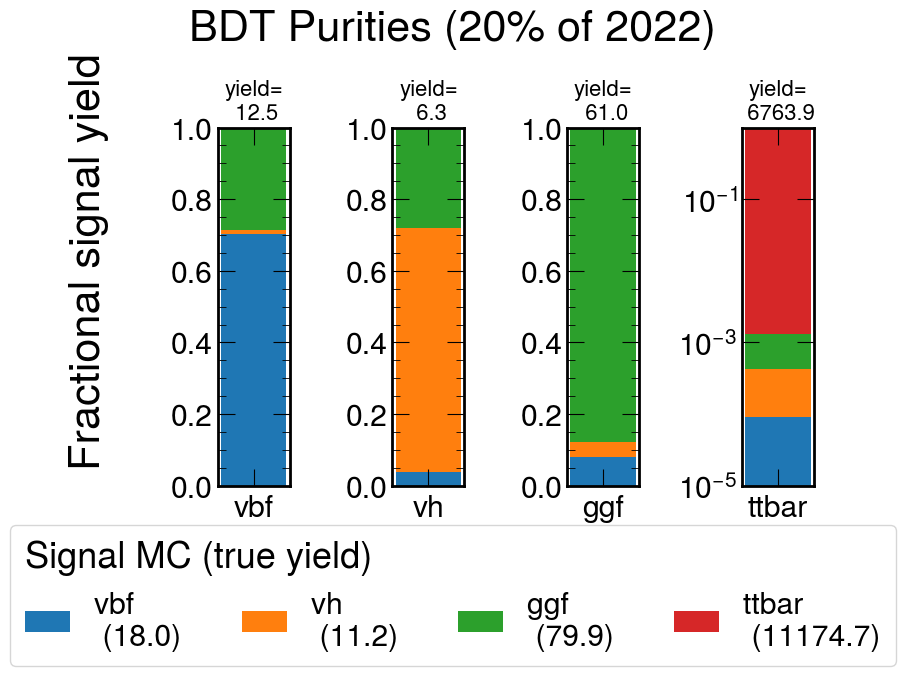

In [21]:
# WP_dict = {
#     'VBF':0.5,
#     'VH':0.5,
#     'ggF':0.2,
#     'ttbar':0.3,
# }

WP_dict = {
    'vbf':0.5,
    'vh':0.5,
    'ggf':0.2,
    'ttbar':0.3,
}
# WP_dict = {
#     'VBF':0.3,
#     'VH':0.3,
#     'ggF':0.3,
#     'ttbar':0.3,
# }

test_file = pd.read_parquet(val_files[0])
true_yields = {}
for name, label in cat2label.items():
    print(name)
    cat_mask = test_file['category'] == name
    # cat_mask = test_file['y'] == label
    true_yields[name] = np.sum(test_file['finalWeight'][cat_mask])
    # true_yields[name] = np.sum(test_file['weight_final'][cat_mask])

# test_data = test_file.drop(['category','y', 'weight', 'finalWeight', 'sum_genWeight', 'weight_nonorm', 'FatJet0_pt', 'FatJet0_msd'], axis=1)
# DM_test = xgb.DMatrix(test_data, label=test_file['y'], missing = np.nan)


fig, axes  = plt.subplots(1,4, figsize = (8,6))
categories = ['vbf', 'vh', 'ggf', 'ttbar'#'tth'#'False'
             ]
# categories = ['VBF', 'VH', 'ggF', 'ttbar'#'tth'#'False'
#              ]
for i in range(4):
    a = SCpurity_plot(axes[i], test_file, use_weights = True, category = categories[i])

hands, legs = axes[3].get_legend_handles_labels()
legs = [f'{l} \n ({round(true_yields[l], 1)})' for j, l in enumerate(legs)]

fig.legend(#[f'{name} \n ({round(true_yields[name], 1)})' for name in categories],
           hands, legs,
           ncol = 4, title= 'Signal MC (true yield)', alignment='left', loc = 'lower center', frameon=True, bbox_to_anchor=(0.5, -0.2))
fig.suptitle('BDT Purities (20% of 2022)', x=0.5, y=0.92)
fig.supylabel('Fractional signal yield')
fig.tight_layout()
# plt.savefig('PurityPlot_3cat_WithAK4PNet_26Jul9.png', bbox_inches="tight")

In [33]:
from common_bb_cc import common_mc

print(common_mc.keys())
# out_cat_dict = {'VBF':0, 'VH':1, 'ggF':2, 'ttbar':3
#                }
out_cat_dict = {'vbf':0, 'vh':1, 'ggf':2, 'ttbar':3
               }

cols = booster.get_booster().feature_names
print(cols)
def get_yield(y, cat_col = 'BDT_score', out_cat = 'VH'):
    out_class = out_cat_dict[out_cat]
    out_mask = y[cat_col] == out_class
    # MC_mask = y['MC_cat'] == MC_cat
    y_mask = out_mask #&MC_mask
    yeeld = np.sum(y[y_mask]['finalWeight'])
    N = np.sum(y_mask)
    return yeeld, N
    
def get_SC_yield(y, cat_col = 'BDT_score', out_cat = 'VH'):
    out_class = cat2label[out_cat]
    # out_mask = y[cat_col] == out_class
    # y = y[cols]
    # y_predict = booster.predict_proba(y[cols])
    SC_Y = score_cut(Y_predict, WP_dict=WP_dict)

    out_mask = SC_Y[cat_col] == out_class

    # MC_mask = y['MC_cat'] == MC_cat
    y_mask = out_mask #&MC_mask
    yeeld = np.sum(y[y_mask]['finalWeight'])
    N = np.sum(y_mask)
    return yeeld, N


dict_keys(['ggf-hbb', 'ggf-hcc', 'vh-hbb', 'vh-hcc', 'vbf-hbb', 'vbf-hcc', 'qcd', 'tth-hbb', 'tth-hcc', 'tt', 'singletop', 'diboson', 'wjets', 'zjets', 'ewkv'])
['nFatJet', 'nJet', 'FatJet0_phi', 'FatJet0_eta', 'FatJet0_n2b1', 'FatJet0_n3b1', 'FatJet1_pt', 'FatJet1_phi', 'FatJet1_eta', 'FatJet1_msd', 'VBFPair_mjj', 'VBFPair_deta', 'FatJet1_ParTPQCD', 'FatJet1_ParTPXbb', 'FatJet1_ParTPXcc', 'FatJet1_ParTPXqq', 'FatJet1_ParTPXcs', 'FatJet1_ParTmassX2p', 'Jet0_pt', 'Jet0_eta', 'Jet0_phi', 'Jet0_mass', 'Jet0_btagPNetQvG', 'Jet1_pt', 'Jet1_eta', 'Jet1_phi', 'Jet1_mass', 'Jet1_btagPNetQvG', 'Jet2_pt', 'Jet2_eta', 'Jet2_phi', 'Jet2_mass', 'Jet2_btagPNetQvG', 'Jet3_pt', 'Jet3_eta', 'Jet3_phi', 'Jet3_mass', 'Jet4_btagPNetQvG', 'JetClosestFatJet0_pt', 'JetClosestFatJet0_eta', 'JetClosestFatJet0_phi', 'JetClosestFatJet0_mass', 'FatJet1_ParTPTopbWq', 'FatJet1_ParTPTopbWqq', 'nJet_outsideFatJet0', 'nJet_opphemFatJet0', 'JetClosestFatJet0_dR', 'JetClosestFatJet0_dijetMass', 'era']


In [ ]:
MAIN_DIR = "/eos/uscms/store/group/lpchbbrun3/"
# dir_name = "skims/26May18/"
dir_name = "skims/26Jun12/"
# dir_name = "lzygala/26Jun12_v15/"
# year='2024'
# years = ['2022', '2022EE', '2023','2023BPix', #'2024'
#         ]
years = ['2022']

samples = {**common_mc}

# samples = {"ggf-hbb": {
#         "GluGluHto2B_M-125",
#         "GluGluHto2B_PT-200_M-125",
#     }}
BDT_cols = booster.get_booster().feature_names


load_columns = ["weight", "FatJet0_msd", "FatJet0_ParTmassX2p", "BDT_score"]
load_columns += BDT_cols
load_columns.remove('era')


for year in years:
    path_to_dir = f"{MAIN_DIR}/{dir_name}/"
    data_dir = Path(path_to_dir) / year
    BDT_yield_table = pd.DataFrame(index = list(out_cat_dict.keys()))
    
    for process, datasets in samples.items():
        print(process)
        BDT_yields = np.zeros(4)
        
        for dataset in datasets:
            events = utils.load_samples(
                data_dir,
                {process: [dataset]},
                columns=load_columns,
                region='signal-all',
                filters=None,
            )
            if events:
                events = pd.DataFrame(events.get(process))
                events.loc[:,'era'] = 2022
                y_predict = booster.predict_proba(events[cols])
                SC_Y = score_cut(y_predict, WP_dict=WP_dict)
                output = events[["finalWeight", "FatJet0_msd", "FatJet0_ParTmassX2p", "BDT_score"]].copy(deep=True)
                output['BDT_SC_score'] = SC_Y
                
                print('Saving scores to ', f'BDT_2022_predictions/{process}_{dataset}.parquet')
                output.to_parquet(f'BDT_2022_predictions/{process}_{dataset}.parquet')

                for i, cat in enumerate(cat2label.keys()):
                    BDT_yields[i] += get_yield(output, cat_col = 'BDT_SC_score', out_cat = cat)[0]
        BDT_yield_table[process] = BDT_yields
    BDT_yield_table.to_csv(f'./BDT_yield_tables_26Sep21/BDT_yield_table_{year}.csv')